In [1]:
import math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Set global seed for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. Complete MiniRacer Environment
class MiniRacer:
    SIZE, ACTIONS = 24, 3
    R, HALF_W, SPEED = 8.0, 2.2, 1.5
    GRASS = np.array([0.16, 0.34, 0.16], np.float32)
    ROAD  = np.array([0.44, 0.44, 0.46], np.float32)
    KERB  = np.array([0.75, 0.72, 0.62], np.float32)
    CAR   = np.array([0.92, 0.20, 0.15], np.float32)

    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        c = (self.SIZE - 1) / 2.0
        yy, xx = np.mgrid[0:self.SIZE, 0:self.SIZE]
        rad = np.sqrt((xx - c)**2 + (yy - c)**2)
        
        self.track = np.tile(self.GRASS, (self.SIZE, self.SIZE, 1)).astype(np.float32)
        self.track[np.abs(rad - self.R) <= self.HALF_W] = self.ROAD
        self.track[np.abs(np.abs(rad - self.R) - self.HALF_W) <= 0.45] = self.KERB
        self._c = c
        self.reset()

    def reset(self):
        self.theta = self.rng.uniform(0, 2 * np.pi)
        self.d = self.rng.uniform(-1.0, 1.0)
        self.phi = self.rng.uniform(-0.2, 0.2)
        self.direction = int(self.rng.choice([-1, 1]))  # Hidden coin flip
        self.t = 0
        return self.observe()

    @property
    def state(self):
        return np.array([self.theta, self.d, self.phi, self.direction], np.float32)

    def observe(self):
        img = self.track.copy()
        r = self.R + self.d
        x = self._c + r * np.cos(self.theta)
        y = self._c + r * np.sin(self.theta)
        xi, yi = int(round(x)), int(round(y))
        for dx in (0, 1):
            for dy in (0, 1):
                px, py = xi + dx - 1, yi + dy - 1
                if 0 <= px < self.SIZE and 0 <= py < self.SIZE:
                    img[py, px] = self.CAR
        return img

    def step(self, action):
        self.phi = float(np.clip(self.phi + 0.16 * (action - 1), -0.7, 0.7))
        self.d = float(self.d + 1.1 * np.sin(self.phi))
        if abs(self.d) > self.HALF_W:
            self.d = float(np.clip(self.d, -self.HALF_W, self.HALF_W))
            self.phi *= 0.4
        self.theta = (self.theta + self.direction * self.SPEED / (self.R + self.d)) % (2 * np.pi)
        reward = 1.0 - abs(self.d) / self.HALF_W
        self.t += 1
        return self.observe(), float(reward), self.t >= 150

Using device: cpu


## Collecting data of random play

Dataset generated: 150 episodes x 150 steps = 22,500 frames (155.5 MB)


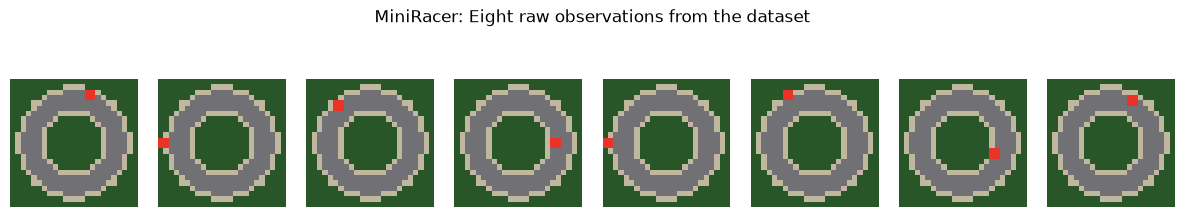

In [2]:
# 3. Collect Dataset of Random Play
env = MiniRacer(seed=SEED)
EPISODES, T = 150, 150

frames = np.zeros((EPISODES, T, 24, 24, 3), np.float32)
actions = np.zeros((EPISODES, T), np.int64)
rewards = np.zeros((EPISODES, T), np.float32)
rng = np.random.default_rng(SEED)

for e in range(EPISODES):
    obs = env.reset()
    for t in range(T):
        a = int(rng.integers(0, 3))
        frames[e, t], actions[e, t] = obs, a
        obs, r, done = env.step(a)
        rewards[e, t] = r

print(f"Dataset generated: {EPISODES} episodes x {T} steps = {EPISODES * T:,} frames ({frames.nbytes / 1e6:.1f} MB)")

# 4. Visualize 8 sample frames
fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
for i in range(8):
    axes[i].imshow(frames[i, i * 9])
    axes[i].axis("off")
fig.suptitle("MiniRacer: Eight raw observations from the dataset", y=1.12)
plt.tight_layout()
plt.show()

### SECTION : 2 || CONVOLUTIONAL VARIATIONAL AUTOENCODER

In [8]:
Z = 16  # 16 numbers to describe the whole frame

class ConvVAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: compresses 24x24 image down to 1152 features
        self.enc = nn.Sequential(
            nn.Conv2d(3, 16, 4, stride=2, padding=1),   # 24x24 -> 12x12
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1),  # 12x12 -> 6x6
            nn.ReLU(),
            nn.Flatten()                                 # 32 * 6 * 6 = 1152[cite: 2]
        )
        self.mu = nn.Linear(1152, Z)
        self.logvar = nn.Linear(1152, Z)
        
        # Decoder: projects 16 numbers back to 24x24 image[cite: 2]
        self.fc = nn.Linear(Z, 1152)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 6x6 -> 12x12[cite: 2]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 12x12 -> 24x24[cite: 2]
            nn.Sigmoid()
        )

    def encode(self, x):
        # Rearrange (Batch, H, W, C) -> (Batch, C, H, W)[cite: 2]
        h = self.enc(x.permute(0, 3, 1, 2))
        return self.mu(h), self.logvar(h)

    def decode(self, z):
        # Project -> Reshape -> Deconv -> Permute back to (Batch, H, W, C)[cite: 2]
        h = self.fc(z).view(-1, 32, 6, 6)
        return self.dec(h).permute(0, 2, 3, 1)

    def forward(self, x):
        mu, logvar = self.encode(x)
        # Reparameterization trick[cite: 2]
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar

In [9]:
# 1. Instantiate model and optimizer
vae = ConvVAE().to(device)
opt = torch.optim.Adam(vae.parameters(), lr=2e-3)

# 2. Prepare data loader (22,500 total frames)
flat = torch.tensor(frames.reshape(-1, 24, 24, 3))
track_t = torch.tensor(env.track).to(device)  # Empty track reference for weighting
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(flat),
    batch_size=256,
    shuffle=True
)

t0 = time.time()
print("Starting training of Vision model (V)...")

for epoch in range(30):
    tot = 0.0
    for (x,) in loader:
        x = x.to(device)
        mu, logvar = vae.encode(x)
        
        # Reparameterize
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        
        # Extra fuzz: train decoder on slightly noisy codes so it handles M's near-misses later[cite: 2]
        z = z + 0.10 * torch.randn_like(z)
        
        # Decode and compute weighted loss[cite: 2]
        xhat = vae.decode(z)
        w = 1.0 + 30.0 * (x - track_t).abs().mean(-1, keepdim=True)
        recon = (w * F.binary_cross_entropy(xhat, x, reduction="none")).sum() / len(x)
        kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu**2 - logvar.exp(), dim=1))
        
        loss = recon + 1.0 * kl
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        tot += loss.item() * len(x)

    if (epoch + 1) % 3 == 0:
        print(f"epoch {epoch+1:2d} | loss: {tot/len(flat):8.2f}")

print(f"V trained in {time.time() - t0:.0f}s ({sum(p.numel() for p in vae.parameters()):,} parameters)")

Starting training of Vision model (V)...
epoch  3 | loss:  1097.04
epoch  6 | loss:  1089.92
epoch  9 | loss:  1068.51
epoch 12 | loss:  1066.56
epoch 15 | loss:  1065.65
epoch 18 | loss:  1064.87
epoch 21 | loss:  1064.35
epoch 24 | loss:  1063.88
epoch 27 | loss:  1063.47
epoch 30 | loss:  1063.16
V trained in 156s (74,467 parameters)


NameError: name 'TEAL' is not defined

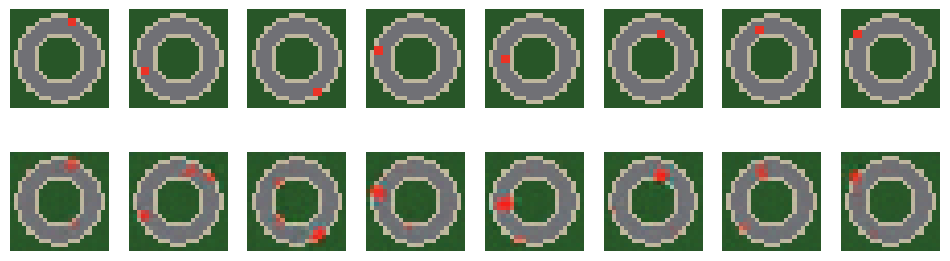

In [10]:
# Set V to evaluation mode (turns off dropout/batchnorm if any, stops unnecessary graph tracking)
vae.eval()

# 1. Reconstruction Test: 8 real frames vs 8 reconstructions from 16 numbers
with torch.no_grad():
    test = flat[:20000:2611][:8].to(device)
    recon, _, _ = vae(test)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(test[i].cpu())
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].cpu().clamp(0, 1))
    axes[1, i].axis("off")

axes[0, 0].set_title("original", loc="left", color=TEAL)
axes[1, 0].set_title("V's reconstruction (from 16 numbers)", loc="left", color=CLAY)
fig.suptitle("V: 1,728 pixels -> 16 numbers -> 1,728 pixels", y=1.02)
plt.tight_layout()
plt.show()

# 2. Latent Walk Test: Interpolate between two frames 26 steps apart
e_walk = 2
with torch.no_grad():
    z1, _ = vae.encode(torch.tensor(frames[e_walk, 0:1]).to(device))
    z2, _ = vae.encode(torch.tensor(frames[e_walk, 26:27]).to(device))
    
    # Create 9 interpolation points between code A (0.0) and code B (1.0)
    steps = torch.linspace(0, 1, 9, device=device).view(-1, 1)
    walk = vae.decode(z1 + steps * (z2 - z1))

fig, axes = plt.subplots(1, 9, figsize=(12, 1.8))
for i in range(9):
    axes[i].imshow(walk[i].cpu().clamp(0, 1))
    axes[i].axis("off")

axes[0].set_title("code A", loc="left", color=TEAL)
axes[-1].set_title("code B", loc="right", color=GOLD)
fig.suptitle("The smooth walk: the car glides around the track between two codes", y=1.15)
plt.tight_layout()
plt.show()